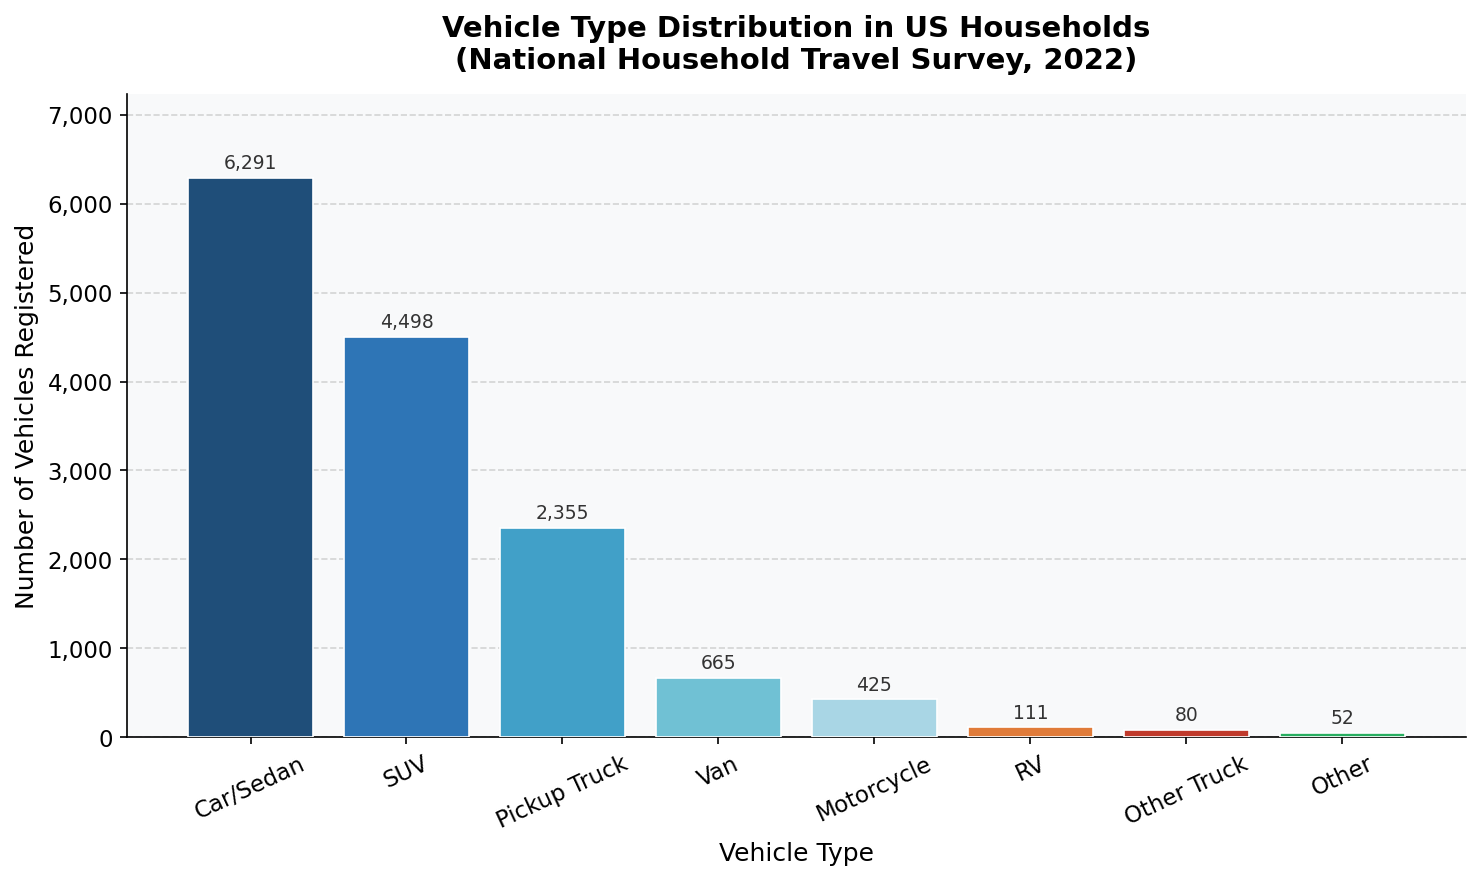

✓ Plot 1 saved: Bar chart – Vehicle type distribution


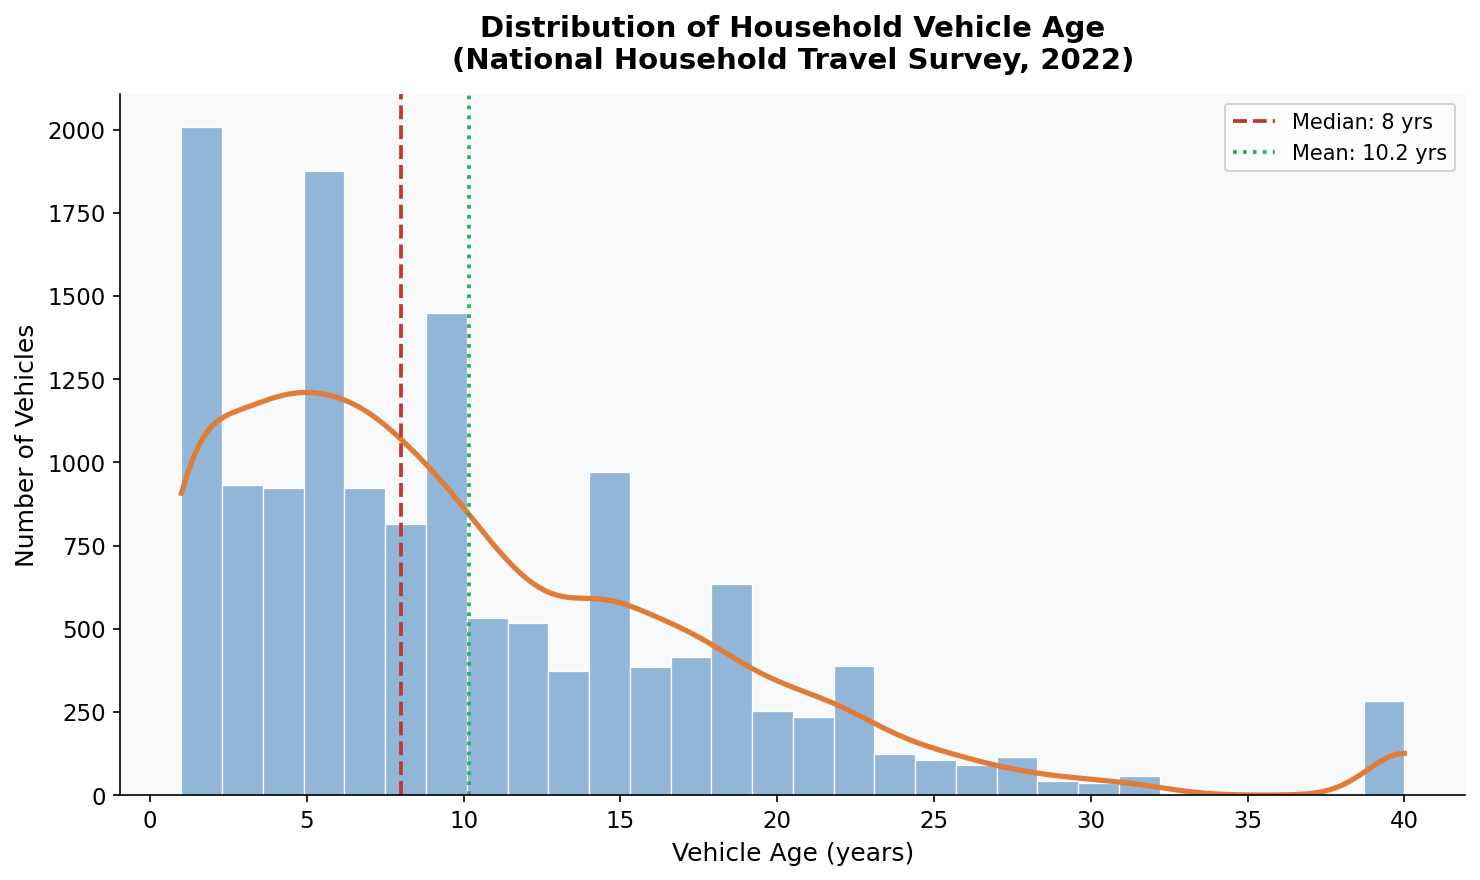

✓ Plot 2 saved: Histogram – Vehicle age distribution


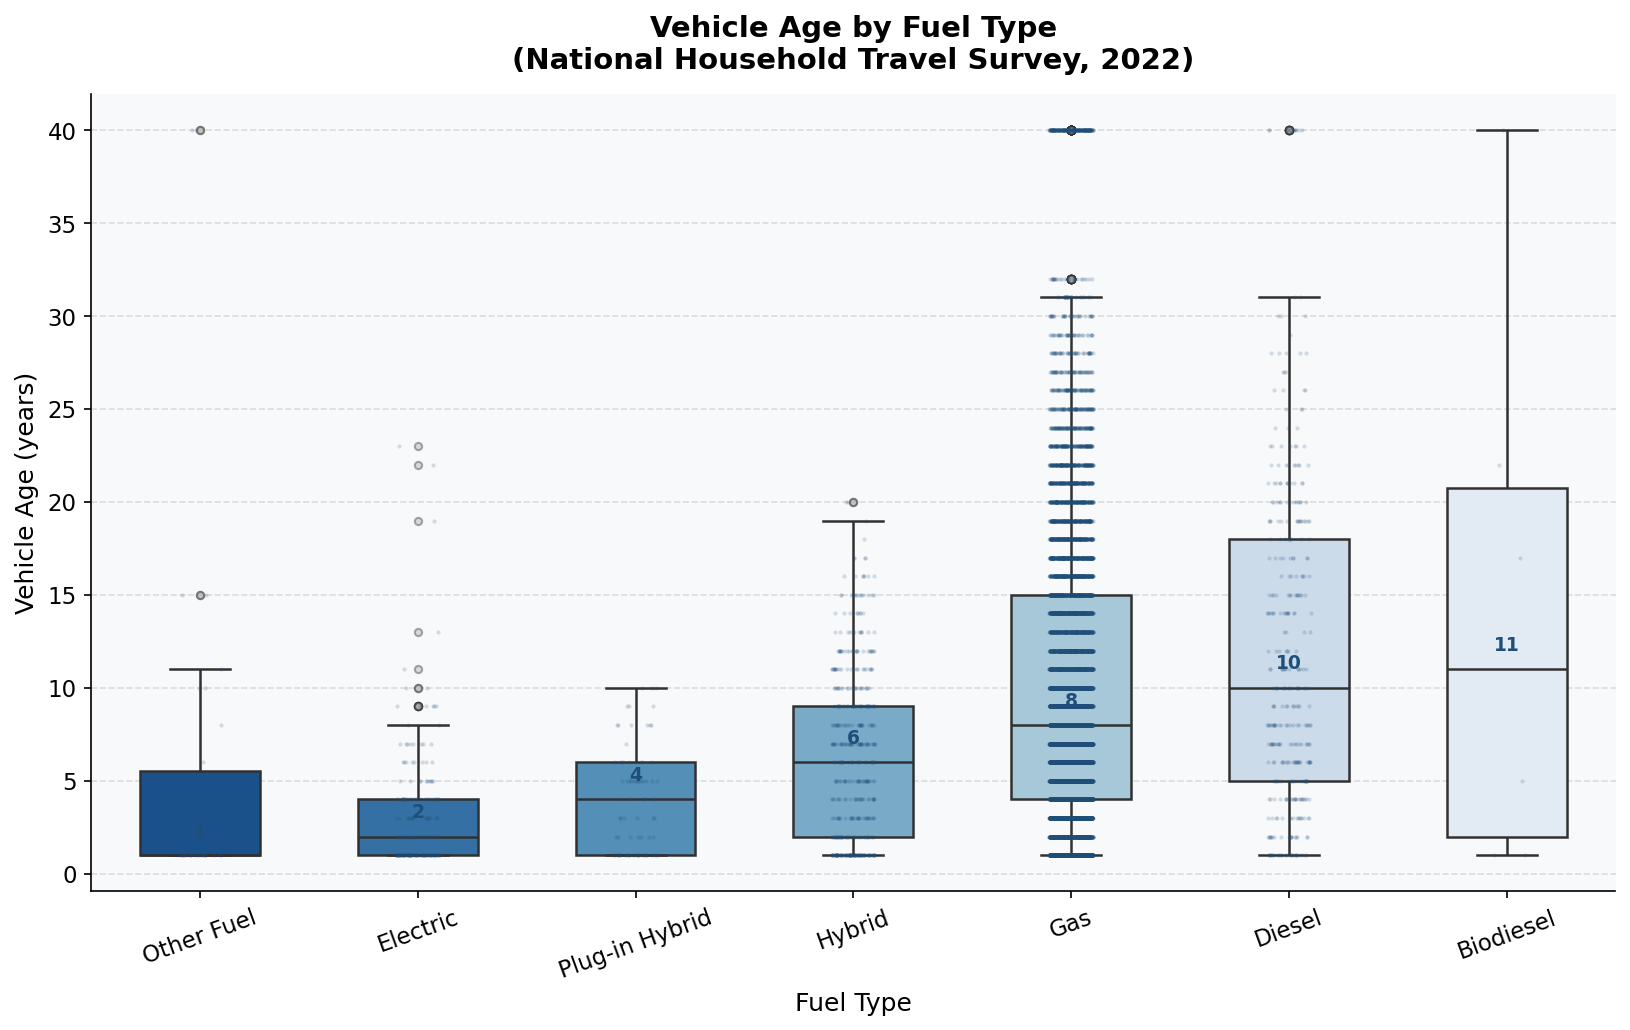

✓ Plot 3 saved: Boxplot – Vehicle age by fuel type


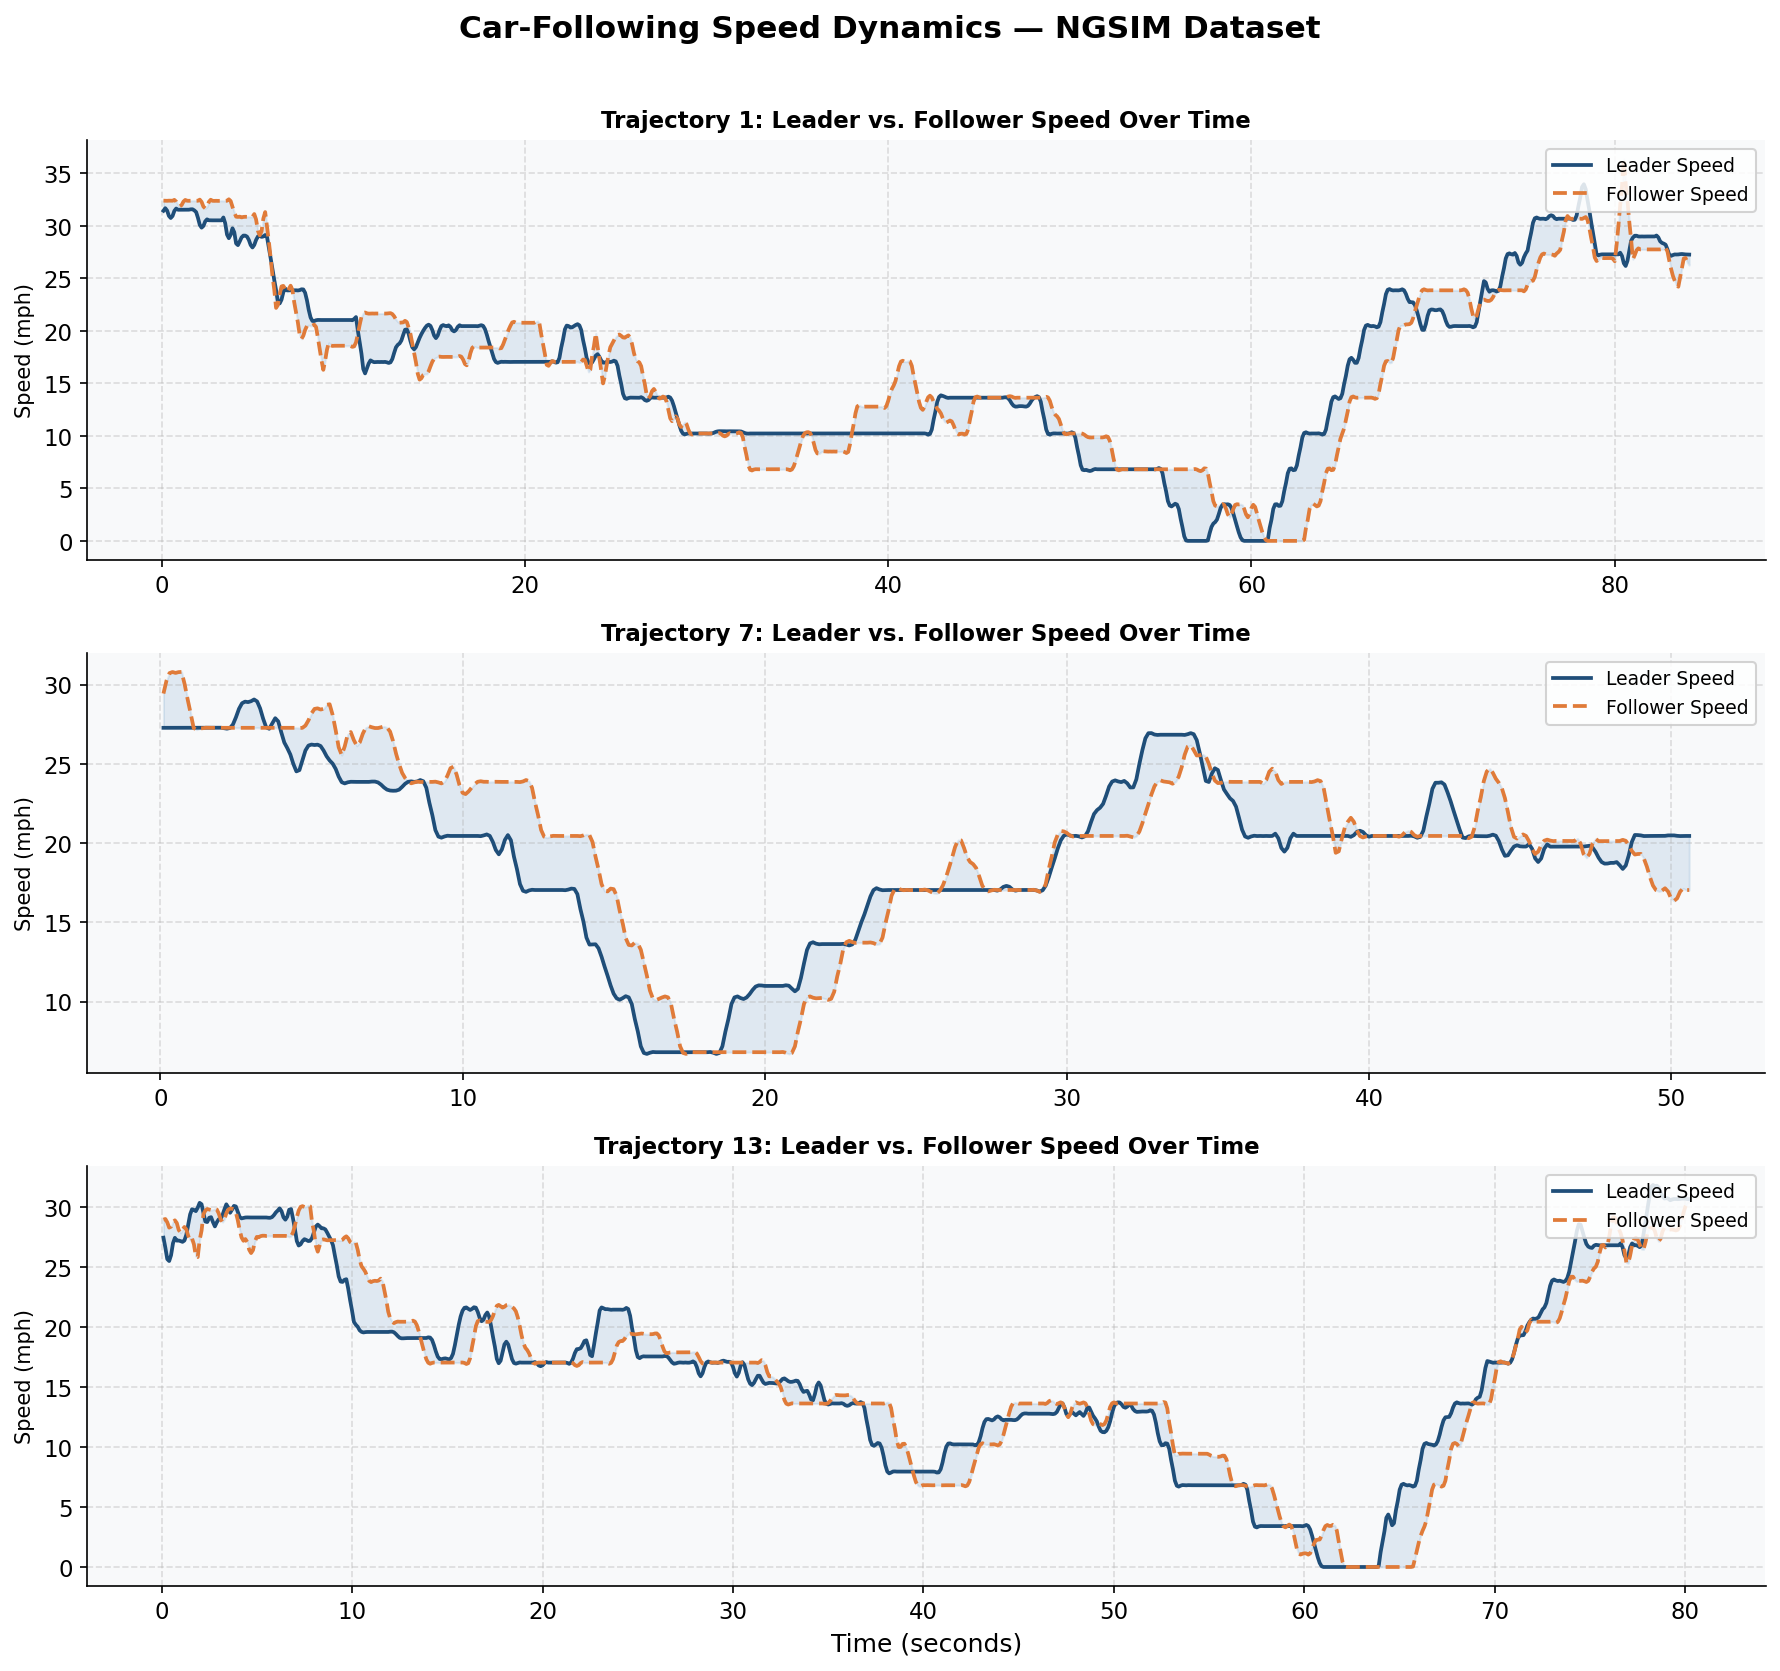

✓ Plot 4 saved: Time-series – Leader vs follower speed


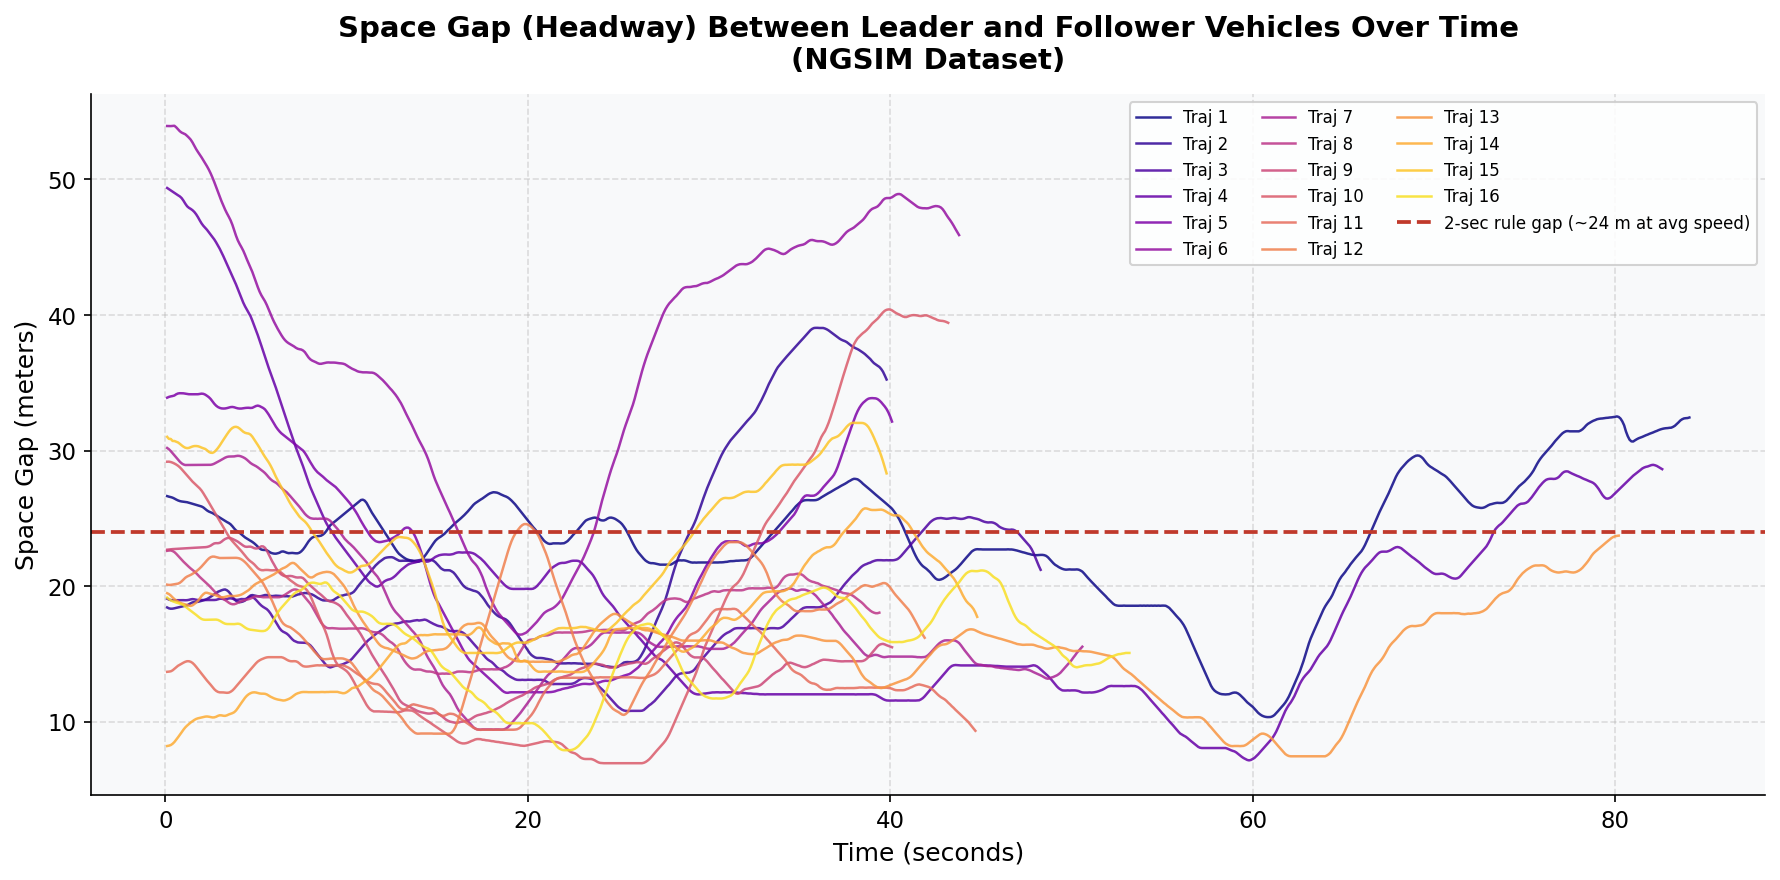

✓ Plot 5 saved: Time-series – Space gap between vehicles


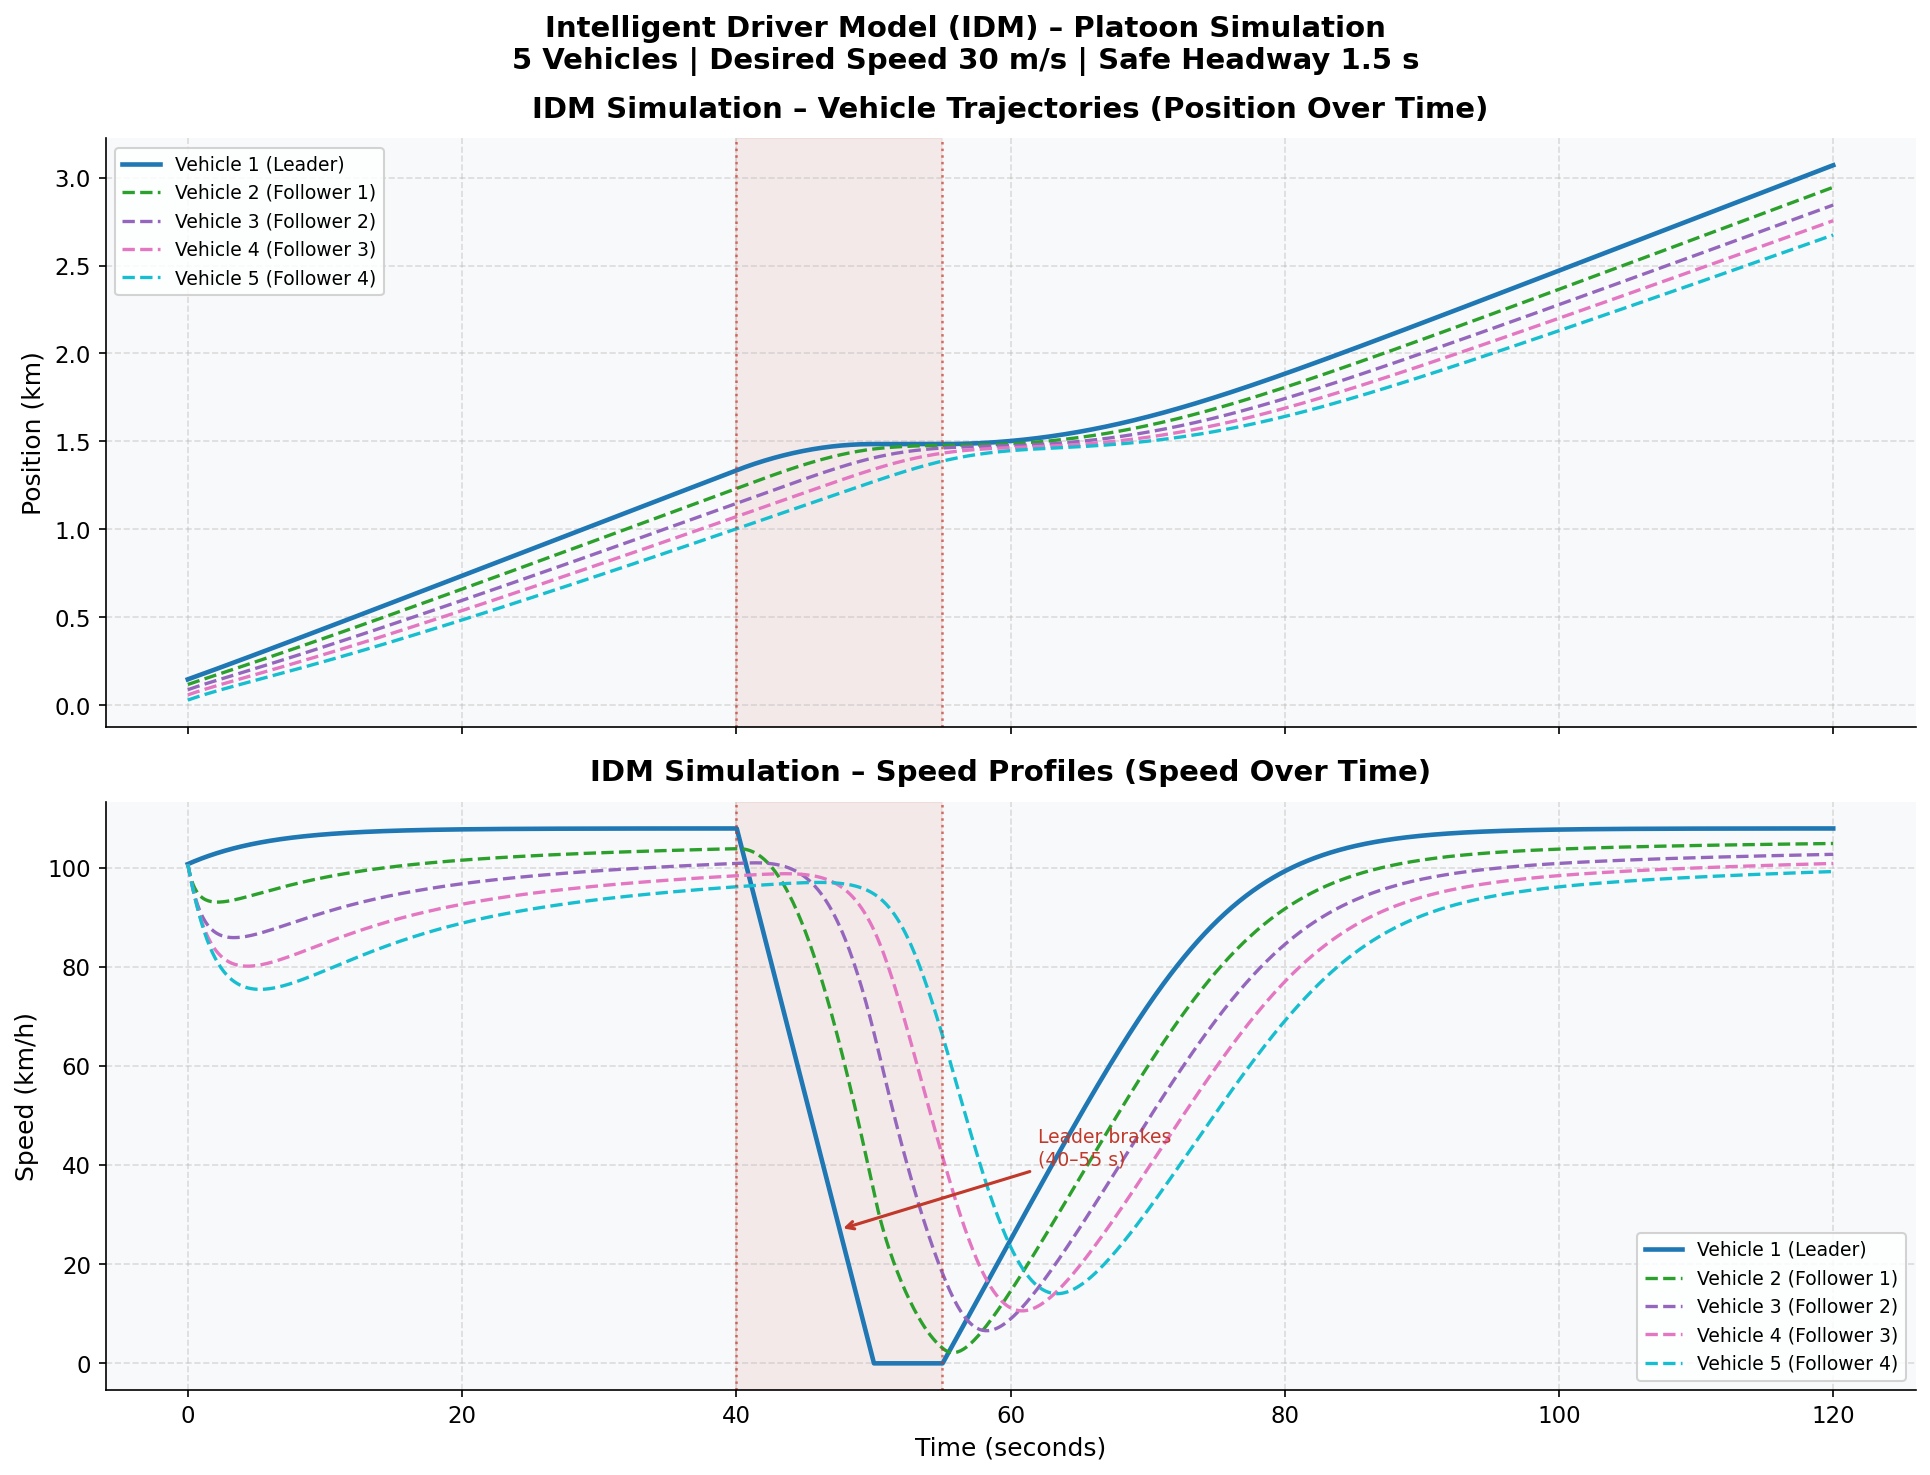

✓ Plot 6 saved: IDM simulation – trajectories & speed profiles

 All 6 plots displayed successfully!


In [10]:
"""
===============================================================================
Transportation Data Analysis & IDM Simulation
Author: Engineering Intern
Date:   March 2026
Datasets:
  - NHTS : National Household Travel Survey (U.S. household vehicle data)
  - NGSIM: Next Generation Simulation (real-world car-following trajectory data)

OUTPUT FILES (saved as PNG images to your Downloads folder):
  plot1_bar_vehicle_type.png
  plot2_histogram_vehicle_age.png
  plot3_boxplot_age_by_fuel.png
  plot4_timeseries_speed.png
  plot5_timeseries_gap.png
  plot6_idm_simulation.png
===============================================================================
"""


# SECTION 0: IMPORT LIBRARIES


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.lines import Line2D

# SECTION 1: GLOBAL STYLE SETTINGS


plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.labelsize":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
})

PALETTE = [
    "#1f4e79",
    "#2e75b6",
    "#41a0c8",
    "#70c1d4",
    "#a9d6e5",
    "#e07b39",
    "#c0392b",
    "#27ae60",
]


# SECTION 2: LOAD DATA


nhts  = pd.read_csv(r"C:\Users\mustaf\Downloads\NHTS(in).csv")
ngsim = pd.read_csv(r"C:\Users\mustaf\Downloads\NGSIM(in).csv")


# SECTION 3: CLEAN AND PREPARE NHTS DATA


nhts_clean = nhts[~nhts["household_income"].isin(
    ["I prefer not to answer", "I don't know"])].copy()

vtype_rename = {
    "Automobile/car/stationwagon":        "Car/Sedan",
    "SUV (Santa Fe, Tahoe, Jeep, etc.)":  "SUV",
    "Pickup Truck":                        "Pickup Truck",
    "Van (Minivan/Cargo/Passenger)":       "Van",
    "Motorcycle/Moped":                    "Motorcycle",
    "Recreational vehicle (RV)/Motorhome": "RV",
    "Other truck":                         "Other Truck",
    "Something else":                      "Other",
}
nhts_clean["vehicle_type_short"] = nhts_clean["vehicle_type"].map(vtype_rename)

fuel_rename = {
    "Gas":                                "Gas",
    "Hybrid, gas/electric, non plug-in":  "Hybrid",
    "Diesel":                             "Diesel",
    "Electric only":                      "Electric",
    "Plug-in hybrid":                     "Plug-in Hybrid",
    "Uses other fuel":                    "Other Fuel",
    "Biodiesel":                          "Biodiesel",
}
nhts_clean["fuel_short"] = nhts_clean["fuel_type"].map(fuel_rename)


# SECTION 4: DERIVE NEW VARIABLES FROM NGSIM DATA


ngsim["gap_m"]             = ngsim["leader_position(m)"] - ngsim["follower_position(m)"]
ngsim["leader_speed_mph"]   = ngsim["leader_speed(m/s)"]   * 2.23694
ngsim["follower_speed_mph"] = ngsim["follower_speed(m/s)"] * 2.23694


# PLOT 1: BAR CHART — Vehicle Type Distribution (NHTS)


fig1, ax1 = plt.subplots(figsize=(10, 6))

vtype_counts = (nhts_clean["vehicle_type_short"]
                .value_counts()
                .sort_values(ascending=False))

bars = ax1.bar(
    vtype_counts.index,
    vtype_counts.values,
    color=PALETTE[:len(vtype_counts)],
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 60,
        f"{int(height):,}",
        ha="center", va="bottom",
        fontsize=9, color="#333333",
    )

ax1.set_title("Vehicle Type Distribution in US Households\n(National Household Travel Survey, 2022)", pad=12)
ax1.set_xlabel("Vehicle Type")
ax1.set_ylabel("Number of Vehicles Registered")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.set_ylim(0, vtype_counts.max() * 1.15)
ax1.tick_params(axis="x", rotation=25)
ax1.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax1.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()
plt.close()
print("✓ Plot 1 saved: Bar chart – Vehicle type distribution")


# PLOT 2: HISTOGRAM — Vehicle Age Distribution (NHTS)


fig2, ax2 = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=nhts_clean,
    x="vehicle_age",
    bins=30,
    color="#2e75b6",
    edgecolor="white",
    linewidth=0.6,
    kde=True,
    ax=ax2,
)

for line in ax2.lines:
    line.set_color("#e07b39")
    line.set_linewidth(2.5)

median_age = nhts_clean["vehicle_age"].median()
mean_age   = nhts_clean["vehicle_age"].mean()

ax2.axvline(median_age, color="#c0392b", linestyle="--", linewidth=1.8, label=f"Median: {median_age:.0f} yrs")
ax2.axvline(mean_age,   color="#27ae60", linestyle=":",  linewidth=1.8, label=f"Mean: {mean_age:.1f} yrs")

ax2.set_title("Distribution of Household Vehicle Age\n(National Household Travel Survey, 2022)", pad=12)
ax2.set_xlabel("Vehicle Age (years)")
ax2.set_ylabel("Number of Vehicles")
ax2.legend(fontsize=10, framealpha=0.85)
ax2.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()
plt.close()
print("✓ Plot 2 saved: Histogram – Vehicle age distribution")



# PLOT 3: BOXPLOT — Vehicle Age by Fuel Type (NHTS)


fig3, ax3 = plt.subplots(figsize=(11, 7))

fuel_order = (nhts_clean.groupby("fuel_short")["vehicle_age"]
              .median()
              .sort_values()
              .index.tolist())

sns.boxplot(
    data=nhts_clean,
    x="fuel_short",
    y="vehicle_age",
    order=fuel_order,
    hue="fuel_short",
    hue_order=fuel_order,
    palette=sns.color_palette("Blues_r", len(fuel_order)),
    legend=False,
    width=0.55,
    linewidth=1.2,
    flierprops=dict(marker="o", markerfacecolor="#aaaaaa", markersize=3.5, alpha=0.4),
    ax=ax3,
)

sns.stripplot(
    data=nhts_clean,
    x="fuel_short",
    y="vehicle_age",
    order=fuel_order,
    color="#1f4e79",
    size=2.0,
    alpha=0.18,
    jitter=True,
    ax=ax3,
)

ax3.set_title("Vehicle Age by Fuel Type\n(National Household Travel Survey, 2022)", pad=12)
ax3.set_xlabel("Fuel Type")
ax3.set_ylabel("Vehicle Age (years)")
ax3.tick_params(axis="x", rotation=20)
ax3.set_facecolor("#f8f9fa")
ax3.grid(axis="y", linestyle="--", alpha=0.4)

for i, fuel in enumerate(fuel_order):
    med = nhts_clean[nhts_clean["fuel_short"] == fuel]["vehicle_age"].median()
    ax3.text(i, med + 0.8, f"{med:.0f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1f4e79")

plt.tight_layout()
plt.show()
plt.close()
print("✓ Plot 3 saved: Boxplot – Vehicle age by fuel type")



# PLOT 4: TIME-SERIES — Leader vs Follower Speed (NGSIM)

fig4, axes4 = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

selected_trajs = [1, 7, 13]
traj_colors = {"leader": "#1f4e79", "follower": "#e07b39"}

for ax, traj_id in zip(axes4, selected_trajs):
    df_t = ngsim[ngsim["trajectory_number"] == traj_id].copy()

    ax.plot(df_t["Time"], df_t["leader_speed_mph"],
            color=traj_colors["leader"], linewidth=1.8, label="Leader Speed")
    ax.plot(df_t["Time"], df_t["follower_speed_mph"],
            color=traj_colors["follower"], linewidth=1.8, linestyle="--", label="Follower Speed")

    ax.fill_between(df_t["Time"],
                    df_t["leader_speed_mph"],
                    df_t["follower_speed_mph"],
                    alpha=0.12, color="#2e75b6")

    ax.set_ylabel("Speed (mph)", fontsize=10)
    ax.set_title(f"Trajectory {traj_id}: Leader vs. Follower Speed Over Time", fontsize=11)
    ax.legend(fontsize=9, loc="upper right", framealpha=0.85)
    ax.grid(linestyle="--", alpha=0.4)
    ax.set_facecolor("#f8f9fa")

axes4[-1].set_xlabel("Time (seconds)")
fig4.suptitle("Car-Following Speed Dynamics — NGSIM Dataset",
              fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
plt.close()
print("✓ Plot 4 saved: Time-series – Leader vs follower speed")



# PLOT 5: TIME-SERIES — Space Gap Between Vehicles (NGSIM)


fig5, ax5 = plt.subplots(figsize=(12, 6))

cmap = plt.get_cmap("plasma")
unique_trajs = sorted(ngsim["trajectory_number"].unique())

for i, traj_id in enumerate(unique_trajs):
    df_t = ngsim[ngsim["trajectory_number"] == traj_id]
    color = cmap(i / len(unique_trajs))
    ax5.plot(df_t["Time"], df_t["gap_m"],
             color=color, linewidth=1.2, alpha=0.85,
             label=f"Traj {traj_id}")

ax5.axhline(24, color="#c0392b", linestyle="--", linewidth=1.8,
            label="2-sec rule gap (~24 m at avg speed)")

ax5.set_title("Space Gap (Headway) Between Leader and Follower Vehicles Over Time\n(NGSIM Dataset)", pad=12)
ax5.set_xlabel("Time (seconds)")
ax5.set_ylabel("Space Gap (meters)")
ax5.legend(ncol=3, fontsize=8, framealpha=0.85, loc="upper right")
ax5.grid(linestyle="--", alpha=0.4)
ax5.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()
plt.close()
print("✓ Plot 5 saved: Time-series – Space gap between vehicles")



# SECTION 5: INTELLIGENT DRIVER MODEL (IDM) SIMULATION


def idm_acceleration(v, delta_v, s, v0=30.0, T=1.5, a_max=1.4,
                     b=2.0, s0=2.0, delta=4):
    """
    Compute IDM acceleration for a single vehicle.

    Parameters
    ----------
    v       : float – current speed of following vehicle (m/s)
    delta_v : float – speed difference (follower - leader) (m/s)
    s       : float – net gap to leader (m)
    v0      : float – desired free-road speed (m/s)
    T       : float – safe time headway (s)
    a_max   : float – max comfortable acceleration (m/s²)
    b       : float – comfortable deceleration (m/s²)
    s0      : float – minimum gap when stopped (m)
    delta   : int   – free-road acceleration exponent

    Returns
    -------
    acc : float – acceleration (m/s²)
    """
    s_star = s0 + max(0.0, v * T + v * delta_v / (2.0 * np.sqrt(a_max * b)))
    acc    = a_max * (1.0 - (v / v0) ** delta - (s_star / max(s, 0.001)) ** 2)
    return acc


def simulate_idm(n_vehicles=5, total_time=120.0, dt=0.1,
                 v0=30.0, T=1.5, a_max=1.4, b=2.0, s0=2.0,
                 initial_gap=25.0, initial_speed=28.0,
                 leader_brake_time=40.0, leader_brake_decel=3.0):
    """
    Simulate a platoon of n_vehicles using the IDM with forward Euler integration.
    The lead vehicle brakes for 15 seconds starting at leader_brake_time.

    Returns: time array, position history, speed history
    """
    steps = int(total_time / dt)
    time  = np.linspace(0, total_time, steps)

    pos   = np.array([(n_vehicles - i) * (initial_gap + 4.5)
                      for i in range(n_vehicles)], dtype=float)
    speed = np.full(n_vehicles, initial_speed, dtype=float)

    pos_hist   = np.zeros((n_vehicles, steps))
    speed_hist = np.zeros((n_vehicles, steps))

    for t_idx in range(steps):
        pos_hist[:, t_idx]   = pos
        speed_hist[:, t_idx] = speed

        acc   = np.zeros(n_vehicles)
        t_now = time[t_idx]

        if leader_brake_time <= t_now < leader_brake_time + 15.0:
            acc[0] = -leader_brake_decel
        else:
            acc[0] = a_max * (1.0 - (speed[0] / v0) ** 4)

        for i in range(1, n_vehicles):
            gap    = max(pos[i - 1] - pos[i] - 4.5, 0.1)
            dv     = speed[i] - speed[i - 1]
            acc[i] = idm_acceleration(speed[i], dv, gap,
                                      v0=v0, T=T, a_max=a_max, b=b, s0=s0)
            acc[i] = max(acc[i], -9.0)

        speed = np.clip(speed + acc * dt, 0, None)
        pos   = pos + speed * dt

    return time, pos_hist, speed_hist



# PLOT 6: IDM SIMULATION — Vehicle Trajectories and Speed Profiles

time_sim, pos_sim, spd_sim = simulate_idm(
    n_vehicles=5, total_time=120.0, dt=0.1,
    v0=30.0, T=1.5, a_max=1.4, b=2.0, s0=2.0,
    initial_gap=25.0, initial_speed=28.0,
    leader_brake_time=40.0, leader_brake_decel=3.0,
)

n_vehicles = pos_sim.shape[0]
veh_colors = plt.get_cmap("tab10")(np.linspace(0, 0.9, n_vehicles))
veh_labels = ["Vehicle 1 (Leader)"] + [f"Vehicle {i+1} (Follower {i})"
                                        for i in range(1, n_vehicles)]

fig6, (ax6a, ax6b) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

for i in range(n_vehicles):
    lw = 2.2 if i == 0 else 1.6
    ls = "-"  if i == 0 else "--"
    ax6a.plot(time_sim, pos_sim[i] / 1000,
              color=veh_colors[i], linewidth=lw, linestyle=ls, label=veh_labels[i])
    ax6b.plot(time_sim, spd_sim[i] * 3.6,
              color=veh_colors[i], linewidth=lw, linestyle=ls, label=veh_labels[i])

for ax in (ax6a, ax6b):
    ax.axvspan(40, 55, alpha=0.08, color="#c0392b", label="_Braking event")
    ax.axvline(40, color="#c0392b", linestyle=":", linewidth=1.2, alpha=0.7)
    ax.axvline(55, color="#c0392b", linestyle=":", linewidth=1.2, alpha=0.7)

ax6a.set_ylabel("Position (km)")
ax6a.set_title("IDM Simulation – Vehicle Trajectories (Position Over Time)", pad=10)
ax6a.legend(fontsize=9, loc="upper left", framealpha=0.85)
ax6a.grid(linestyle="--", alpha=0.4)
ax6a.set_facecolor("#f8f9fa")

ax6b.set_xlabel("Time (seconds)")
ax6b.set_ylabel("Speed (km/h)")
ax6b.set_title("IDM Simulation – Speed Profiles (Speed Over Time)", pad=10)
ax6b.legend(fontsize=9, loc="lower right", framealpha=0.85)
ax6b.grid(linestyle="--", alpha=0.4)
ax6b.set_facecolor("#f8f9fa")

ax6b.annotate(
    "Leader brakes\n(40–55 s)",
    xy=(47.5, spd_sim[0, int(47.5 / 0.1)] * 3.6),
    xytext=(62, 40),
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.5),
    fontsize=9, color="#c0392b",
)

fig6.suptitle("Intelligent Driver Model (IDM) – Platoon Simulation\n"
              "5 Vehicles | Desired Speed 30 m/s | Safe Headway 1.5 s",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close()
print("✓ Plot 6 saved: IDM simulation – trajectories & speed profiles")

print("\n All 6 plots displayed successfully!")